# 04 · Do friends' notifications make you train? (causal inference)

Every set a user logs pushes a notification to their friends. Does receiving one make you
more likely to do a set soon after?

**The naive answer is biased.** Friends are often active at the same time for reasons that have
nothing to do with notifications: they train together, share a schedule, have a good day as a
group. Then "I got a notification" and "I did a set" happen together even if notifications do
nothing.

```
            together session / shared routine
               ↙                      ↘
   friend logs a set  ──notification──▶  you log a set
```

The simulator plants exactly this confounder (`together_prob`, `together_boost`) plus a true
effect: while a delivered notification is less than an hour old, your set rate is multiplied
by **1.5**.

**The fix is an experiment.** In a *micro-randomized trial* each notification is delivered with
probability 50%. Whether a particular notification reached you is then random, independent of
the together-session, so comparing delivered vs. not-delivered is unbiased.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from costuel_analysis import SimConfig, simulate
from costuel_analysis.plotting import use_style, subtitle, date_axis, SERIES, REFERENCE, MUTED, INK_SECONDARY, GRID

use_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
from costuel_analysis.causal import build_slots, naive_effect, notification_outcomes, proximal_effect, randomized_effect

## Part 1 · Can we recover the planted effect?

Two designs (observational: every notification delivered; randomized: 50% delivered) crossed
with two truths: a real effect of **1.5**, and **no effect** at all (a placebo check).
The target is the planted parameter: the set-rate ratio *while notified vs. not notified*.

* **Naive**: 10-minute slots in the hour after a notification vs. all other slots, adjusting
  for user and hour of day (Poisson model, SEs clustered by user).
* **Randomized**: only slots where a friend *did* log a set in the last hour; the comparison is
  delivered vs. not delivered, stratified by how many friend sets there were.

In [2]:
scenarios = {
    "observational · effect 1.5": SimConfig(),
    "observational · no effect": SimConfig(notification_effect=0.0),
    "randomized 50% · effect 1.5": SimConfig(delivery_prob=0.5),
    "randomized 50% · no effect": SimConfig(delivery_prob=0.5, notification_effect=0.0),
}
sims, rows = {}, []
for name, c in scenarios.items():
    r = sims[name] = simulate(c)
    slots = build_slots(r.entries, r.notifications, r.daily)
    est = {"naive": naive_effect(slots)}
    if c.delivery_prob < 1:
        est["randomized"] = randomized_effect(slots)
    for estimator, e in est.items():
        rows.append({"scenario": name, "estimator": estimator, "truth": c.true_hazard_ratio,
                     "estimate": e["hazard_ratio"], "ci_low": e["ci_low"], "ci_high": e["ci_high"]})
results = pd.DataFrame(rows)
results["truth inside CI"] = (results["ci_low"] <= results["truth"]) & (results["truth"] <= results["ci_high"])
results.set_index(["scenario", "estimator"]).round(3)

truth  estimate  ci_low  ci_high  truth inside CI
scenario                    estimator                                                    
observational · effect 1.5  naive         1.5     1.784   1.698    1.874            False
observational · no effect   naive         1.0     1.189   1.135    1.246            False
randomized 50% · effect 1.5 naive         1.5     1.699   1.623    1.778            False
                            randomized    1.5     1.479   1.403    1.560             True
randomized 50% · no effect  naive         1.0     1.152   1.103    1.203            False
                            randomized    1.0     1.009   0.962    1.058             True

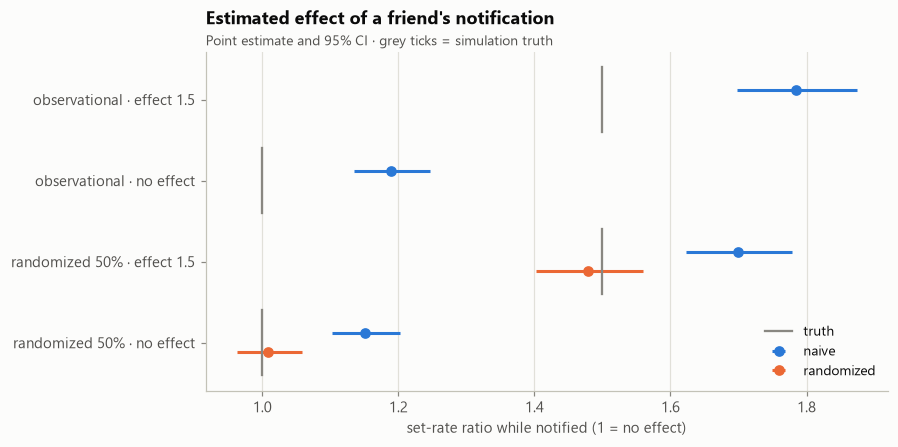

In [3]:
order = list(scenarios)
fig, ax = plt.subplots(figsize=(8, 4))
for color, (k, est) in zip(SERIES, enumerate(["naive", "randomized"])):
    sub = results[results["estimator"] == est]
    y = np.array([order.index(s) for s in sub["scenario"]]) + (k - 0.5) * 0.24
    ax.errorbar(sub["estimate"], y, xerr=[sub["estimate"] - sub["ci_low"], sub["ci_high"] - sub["estimate"]],
                fmt="o", color=color, markersize=6, capsize=0, elinewidth=2, label=est)
for i, s in enumerate(order):
    t = scenarios[s].true_hazard_ratio
    ax.plot([t, t], [i - 0.4, i + 0.4], color=REFERENCE, linewidth=1.5)
ax.plot([], [], color=REFERENCE, linewidth=1.5, label="truth")
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.grid(axis="x")
ax.set_xlabel("set-rate ratio while notified (1 = no effect)")
ax.legend(loc="lower right")
ax.set_title("Estimated effect of a friend's notification", pad=18)
subtitle(ax, "Point estimate and 95% CI · grey ticks = simulation truth")
plt.show()

### Reading the results

* **Naive** estimates are too high in every world, and in the placebo worlds they "find" an
  effect of 15-20% that does not exist: pure confounding by the together-sessions.
* The **randomized** estimate is centred on 1 in the placebo world and lands on the truth when
  the effect is real.

One subtlety: across repeated runs the randomized hazard ratio sits slightly *below* 1.5. This
is a known property of hazard ratios (Hernán, 2010, *The hazards of hazard ratios*): notified
users reach 100 sooner and leave the "still at risk" pool, so the exposed slots that remain are
enriched with slower days. Removing the goal (nobody ever leaves the pool) makes it disappear:

In [4]:
rows = []
for goal in (100, 100_000):
    for seed in range(3):
        r = simulate(SimConfig(delivery_prob=0.5, goal=goal, seed=100 + seed, n_days=60))
        rows.append({"goal": "100 (people finish)" if goal == 100 else "unreachable (nobody leaves)",
                     "seed": seed, "randomized HR": randomized_effect(build_slots(r.entries, r.notifications, r.daily))["hazard_ratio"]})
depletion = pd.DataFrame(rows).groupby("goal")["randomized HR"].agg(["mean", "min", "max"])
depletion["truth"] = 1.5
depletion

,mean,min,max,truth
goal,,,,
100 (people finish),1.464,1.436,1.518,1.5
unreachable (nobody leaves),1.503,1.476,1.537,1.5


## Part 2 · What is one more notification worth?

The product question is slightly different: *if the app delivers this notification, how many
more sets happen in the next hour?* That is the **proximal (excursion) effect** that
micro-randomized trials target (Boruvka et al., 2018). The unit is a notification, and we only
condition on what was known *before* randomizing it (the recipient was still below 100).

It is **not** the 1.5 above, by design: friends log sets in bursts, so most notifications reach
someone who has already been notified in the last hour, and an extra one adds little.

In [5]:
r = sims["randomized 50% · effect 1.5"]
outcomes = notification_outcomes(r.entries, r.notifications, r.daily)
available = outcomes[outcomes["available"]]
print(f"{len(available):,} notifications to users still below 100 · "
      f"{(available['prior_notifications'] > 0).mean():.0%} arrived within an hour of another one")

rows = []
for label, subset in [("all notifications", outcomes),
                      ("first in the hour", outcomes[outcomes["prior_notifications"] == 0]),
                      ("after 1 other", outcomes[outcomes["prior_notifications"] == 1]),
                      ("after 2+ others", outcomes[outcomes["prior_notifications"] >= 2])]:
    p = proximal_effect(subset)
    rows.append({"notifications": label, "n": p["n_notifications"], "sets next hour (delivered)": p["sets_next_hour_delivered"],
                 "sets next hour (not delivered)": p["sets_next_hour_not_delivered"],
                 "rate ratio": p["rate_ratio"], "ci_low": p["ci_low"], "ci_high": p["ci_high"]})
marginal = pd.DataFrame(rows).set_index("notifications")
placebo = proximal_effect(notification_outcomes(*(lambda s: (s.entries, s.notifications, s.daily))(sims["randomized 50% · no effect"])))
print(f"placebo world (no effect): rate ratio {placebo['rate_ratio']:.3f} [{placebo['ci_low']:.3f}, {placebo['ci_high']:.3f}]")
marginal.round(3)

100,684 notifications to users still below 100 · 72% arrived within an hour of another one


placebo world (no effect): rate ratio 1.019 [0.990, 1.049]


,n,sets next hour (delivered),sets next hour (not delivered),rate ratio,ci_low,ci_high
notifications,,,,,,
all notifications,100684,0.293,0.265,1.109,1.079,1.141
first in the hour,28101,0.260,0.209,1.254,1.184,1.329
after 1 other,24293,0.283,0.258,1.113,1.045,1.184
after 2+ others,48290,0.317,0.302,1.052,1.018,1.087


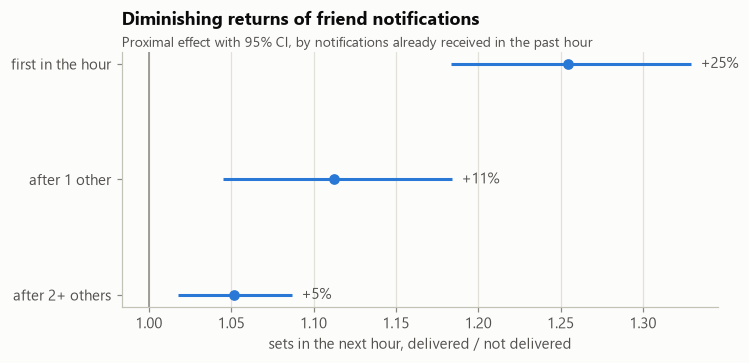

In [6]:
sub = marginal.iloc[1:]
fig, ax = plt.subplots(figsize=(7, 3))
y = np.arange(len(sub))
ax.errorbar(sub["rate ratio"], y, xerr=[sub["rate ratio"] - sub["ci_low"], sub["ci_high"] - sub["rate ratio"]],
            fmt="o", color=SERIES[0], markersize=6, capsize=0, elinewidth=2)
ax.axvline(1, color=REFERENCE, linewidth=1)
for yi, (_, row) in zip(y, sub.iterrows()):
    ax.annotate(f"+{row['rate ratio'] - 1:.0%}", (row["ci_high"], yi), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_SECONDARY)
ax.set_yticks(y, sub.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.grid(axis="x")
ax.set_xlabel("sets in the next hour, delivered / not delivered")
ax.set_title("Diminishing returns of friend notifications", pad=18)
subtitle(ax, "Proximal effect with 95% CI, by notifications already received in the past hour")
plt.show()

## How long would the real experiment need to run?

Same randomized design, 60 users, different durations: width of the 95% CI of the proximal
effect of a notification (all notifications).

In [7]:
rows = []
for days in (14, 30, 60, 120):
    r = simulate(SimConfig(delivery_prob=0.5, n_days=days, seed=21))
    p = proximal_effect(notification_outcomes(r.entries, r.notifications, r.daily))
    rows.append({"days": days, "notifications": p["n_notifications"], "effect": p["rate_ratio"],
                 "ci_low": p["ci_low"], "ci_high": p["ci_high"], "ci width": p["ci_high"] - p["ci_low"]})
pd.DataFrame(rows).set_index("days")

,notifications,effect,ci_low,ci_high,ci width
days,,,,,
14,11943,1.101,1.018,1.191,0.173
30,27085,1.095,1.051,1.140,0.089
60,54138,1.124,1.089,1.160,0.072
120,110540,1.084,1.065,1.105,0.040


## Takeaways and what to do in the real app

1. **Don't trust the observational comparison.** Here it overstates the effect and even
   invents one when there is none.
2. **Randomize delivery.** Holding back a random share of friend notifications is cheap and
   turns every notification into a small experiment; the placebo checks show the design is valid.
3. **Name the estimand.** "Rate while notified" (1.5), "one more notification" (about +10%) and
   "the first notification of the hour" (about +25%) are three different, all correct, answers.
4. **Throttle.** The first notification of the hour carries most of the value; later ones add
   little and cost attention. A per-recipient cap (e.g. one friend notification per hour) is the
   obvious product change - and it should itself be tested.
5. **Log the decision.** The app must store each notification with its `delivered` flag (today it
   only sends them). Then this notebook runs unchanged on real data (`export_analysis_data`).